"""
Fixed Graph Plotter — IV_doping.iv
====================================
Fixes the 4 broken graphs:
  ✔ Image 1 — Current Components (Total J, Recombination, Generation)
  ✔ Image 2 — Dark I-V Curve
  ✔ Image 3 — Semi-log Dark I-V Curve
  ✔ Image 9 — Recombination Mechanisms (SRH, Radiative, Auger)

ROOT CAUSE OF THE BUG:
  The file contains many simulation blocks concatenated together.
  The old code read ALL blocks into one array, causing spiky garbage plots.
  This script extracts ONLY the correct single-shot blocks:
    → Simulation #3  = dark I-V          (lines 1–63)
    → Simulation #4  = illuminated I-V   (lines 65–143)

HOW TO RUN:
  Place this file in the same folder as IV_doping.iv
  pip install numpy matplotlib
  python plot_fixed_graphs.py
"""

In [22]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


filename = "IV_doping.iv"

In [23]:
# ── 1. READ FILE ─────────────────────────────────────────

with open(filename, "r", errors="ignore") as f:
    lines = f.readlines()

# ── 2. EXTRACT NUMERIC DATA BLOCKS ───────────────────────

blocks = []
current_block = []

for line in lines:
    parts = line.strip().split()

    if len(parts) >= 11:
        try:
            row = [float(p) for p in parts[:11]]
            current_block.append(row)
            continue
        except:
            pass

    # If non-numeric line encountered → close block
    if current_block:
        blocks.append(np.array(current_block))
        current_block = []

# Catch last block
if current_block:
    blocks.append(np.array(current_block))

print(f"Found {len(blocks)} data blocks")


Found 245 data blocks


In [24]:
# ── 3. SELECT VALID BLOCKS ───────────────────────────────

# Choose:
# smallest current magnitude → DARK
# largest current magnitude → ILLUMINATED

block_currents = [np.mean(np.abs(b[:,1])) for b in blocks]

dark_block = blocks[np.argmin(block_currents)]
ill_block  = blocks[np.argmax(block_currents)]

print("Dark block size:", dark_block.shape)
print("Illuminated block size:", ill_block.shape)

Dark block size: (40, 11)
Illuminated block size: (41, 11)


In [25]:
# ── 4. EXTRACT DATA ─────────────────────────────────────

# columns
# 0=v, 1=jtot, 2=j_rec, 3=j_gen, ..., 8=SRH, 9=Rad, 10=Auger

d_v = dark_block[:,0]
d_j = dark_block[:,1]

i_v = ill_block[:,0]
i_j = ill_block[:,1]
i_rec = ill_block[:,2]
i_gen = ill_block[:,3]
i_srh = ill_block[:,8]
i_rad = ill_block[:,9]
i_aug = ill_block[:,10]

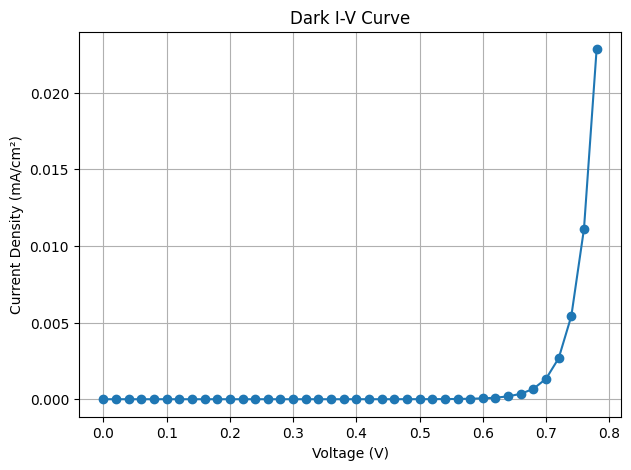

In [26]:
# ── 5. PLOT DARK I-V ────────────────────────────────────

plt.figure(figsize=(7,5))
plt.plot(d_v, d_j, 'o-', linewidth=1.5)
plt.xlabel("Voltage (V)")
plt.ylabel("Current Density (mA/cm²)")
plt.title("Dark I-V Curve")
plt.grid(True)
plt.savefig("IV_dark.png", dpi=300)
plt.show()

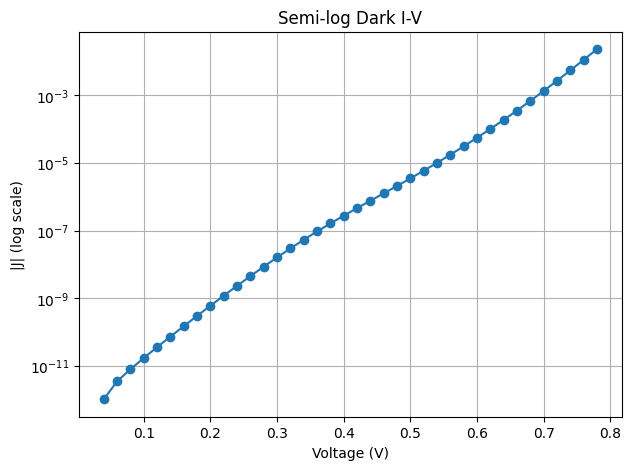

In [27]:
# ── 6. SEMI-LOG ─────────────────────────────────────────

mask = np.abs(d_j) > 1e-12

plt.figure(figsize=(7,5))
plt.semilogy(d_v[mask], np.abs(d_j[mask]), 'o-')
plt.xlabel("Voltage (V)")
plt.ylabel("|J| (log scale)")
plt.title("Semi-log Dark I-V")
plt.grid(True)
plt.savefig("IV_log.png", dpi=300)
plt.show()

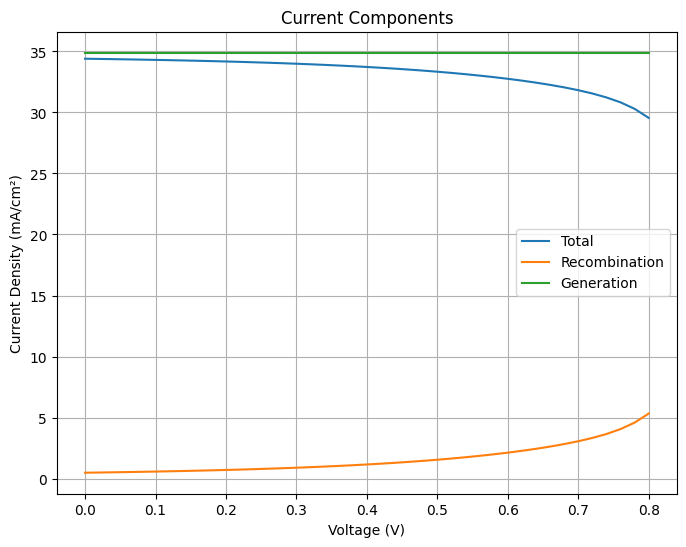

In [28]:
# ── 7. CURRENT COMPONENTS ───────────────────────────────

plt.figure(figsize=(8,6))
plt.plot(i_v, -i_j, label="Total")
plt.plot(i_v, i_rec, label="Recombination")
plt.plot(i_v, i_gen, label="Generation")

plt.xlabel("Voltage (V)")
plt.ylabel("Current Density (mA/cm²)")
plt.title("Current Components")
plt.legend()
plt.grid(True)
plt.savefig("components.png", dpi=300)
plt.show()

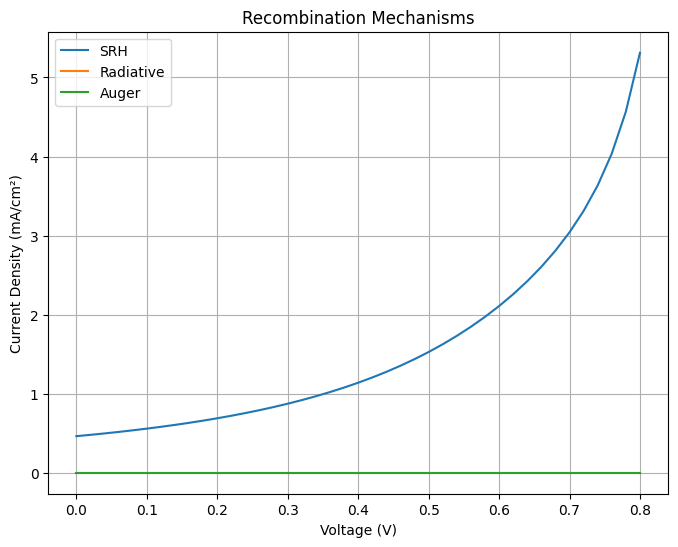

✓ All graphs plotted successfully


In [29]:
# ── 8. RECOMBINATION ────────────────────────────────────

plt.figure(figsize=(8,6))
plt.plot(i_v, i_srh, label="SRH")
plt.plot(i_v, i_rad, label="Radiative")
plt.plot(i_v, i_aug, label="Auger")

plt.xlabel("Voltage (V)")
plt.ylabel("Current Density (mA/cm²)")
plt.title("Recombination Mechanisms")
plt.legend()
plt.grid(True)
plt.savefig("recombination.png", dpi=300)
plt.show()

print("✓ All graphs plotted successfully")